<a href="https://colab.research.google.com/github/ps-research/The-Language-of-AI-Liability/blob/main/Obligation_Complexity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Technique 3: Obligation Complexity Analysis
## ACL ARR March 2026: The Language of AI Liability



In [ ]:
!python -m spacy download en_core_web_trf
!pip install spacy-curated-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.9/237.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 18.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ── Cell 1: Setup and load ──

import json
import re
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from collections import defaultdict

BASE_DIR = Path("/content/drive/MyDrive/ACL SRW TEXTS")
OUTPUT_DIR = BASE_DIR / "processed"
FIGURE_DIR = BASE_DIR / "figures"

with open(OUTPUT_DIR / "preprocessed_corpus.json", "r", encoding="utf-8") as f:
    results = json.load(f)

nlp = spacy.load("en_core_web_trf")
nlp.max_length = 700_000

CORPUS_FILES = {
    "eu_ai_act":   "eu_ai_act_binding.txt",
    "china_genai":  "china_genai_measures.txt",
    "south_korea":  "south_korea_ai_basic_act.txt",
    "ca_sb1047":    "ca_sb1047.txt",
    "ca_sb53":      "ca_sb53.txt",
    "ca_sb942":     "ca_sb942.txt",
    "ca_ab2013":    "ca_ab2013.txt",
    "co_sb205":     "co_sb205.txt",
    "tx_traiga":    "tx_traiga.txt",
    "il_hb3773":    "il_hb3773.txt",
}

LAW_ORDER = [
    "eu_ai_act", "china_genai", "south_korea",
    "ca_sb1047", "ca_sb53", "ca_sb942", "ca_ab2013",
    "co_sb205", "tx_traiga", "il_hb3773",
]

LAW_LABELS = {
    "eu_ai_act":   "EU AI Act",
    "china_genai":  "China GenAI Measures",
    "south_korea":  "South Korea AI Basic Act",
    "ca_sb1047":    "CA SB 1047 (vetoed)",
    "ca_sb53":      "CA SB 53",
    "ca_sb942":     "CA SB 942",
    "ca_ab2013":    "CA AB 2013",
    "co_sb205":     "CO SB 205",
    "tx_traiga":    "TX TRAIGA",
    "il_hb3773":    "IL HB 3773",
}

print(f"Loaded {len(results)} laws")

Loaded 10 laws


In [ ]:
# ── Cell 2: Metric 1 — Dependency tree depth ──

def tree_depth(token):
    """Compute depth of a token in the dependency tree.
    Root has depth 0."""
    depth = 0
    while token.head != token:
        depth += 1
        token = token.head
    return depth


def max_tree_depth(doc):
    """Maximum dependency tree depth across all tokens in a doc."""
    if len(doc) == 0:
        return 0
    return max(tree_depth(tok) for tok in doc)


print("Computing dependency tree depths...")

depth_results = {}
for law_id in LAW_ORDER:
    sents = results[law_id]["sentences"]
    obligation_sents = [s for s in sents if s["is_obligation"]]

    depths = []
    for s in obligation_sents:
        doc = nlp(s["text"])
        d = max_tree_depth(doc)
        depths.append(d)

    mean_depth = np.mean(depths) if depths else 0
    median_depth = np.median(depths) if depths else 0
    std_depth = np.std(depths) if depths else 0

    depth_results[law_id] = {
        "mean": float(mean_depth),
        "median": float(median_depth),
        "std": float(std_depth),
        "n": len(depths),
        "depths": depths,
    }

    print(f"  {law_id:<22} mean={mean_depth:.1f}  "
          f"median={median_depth:.0f}  std={std_depth:.1f}  n={len(depths)}")

Computing dependency tree depths...
  eu_ai_act              mean=9.4  median=8  std=5.4  n=710
  china_genai            mean=9.8  median=8  std=4.2  n=16
  south_korea            mean=9.9  median=9  std=4.0  n=102
  ca_sb1047              mean=10.6  median=10  std=4.6  n=56
  ca_sb53                mean=9.8  median=8  std=4.5  n=54
  ca_sb942               mean=10.3  median=9  std=4.0  n=13
  ca_ab2013              mean=10.0  median=10  std=0.8  n=3
  co_sb205               mean=11.8  median=12  std=4.9  n=25
  tx_traiga              mean=10.9  median=8  std=10.2  n=43
  il_hb3773              mean=8.2  median=8  std=3.1  n=16


In [ ]:
# ── Cell 3: Metric 2 — Conditional nesting density ──

CONDITIONAL_MARKERS = re.compile(
    r'\bif\b'
    r'|\bunless\b'
    r'|\bprovided\s+that\b'
    r'|\bexcept\s+(?:when|where|that|as)\b'
    r'|\bto\s+the\s+extent\s+that\b'
    r'|\bsubject\s+to\b'
    r'|\bnotwithstanding\b'
    r'|\bin\s+the\s+event\s+that\b'
    r'|\bwhere\b'
    r'|\bin\s+(?:the\s+)?case\s+(?:of|that|where)\b'
    r'|\bprovided\b',
    re.IGNORECASE
)

print("\nComputing conditional nesting density...")

conditional_results = {}
for law_id in LAW_ORDER:
    sents = results[law_id]["sentences"]
    obligation_sents = [s for s in sents if s["is_obligation"]]

    conditional_counts = []
    for s in obligation_sents:
        matches = CONDITIONAL_MARKERS.findall(s["text"])
        conditional_counts.append(len(matches))

    total_conditionals = sum(conditional_counts)
    n_oblig = len(obligation_sents)
    density = total_conditionals / n_oblig if n_oblig > 0 else 0

    conditional_results[law_id] = {
        "total_conditionals": total_conditionals,
        "n_obligation": n_oblig,
        "density": float(density),
        "counts": conditional_counts,
    }

    print(f"  {law_id:<22} conditionals={total_conditionals:>4}  "
          f"oblig_sents={n_oblig:>3}  density={density:.2f}")


Computing conditional nesting density...
  eu_ai_act              conditionals= 418  oblig_sents=710  density=0.59
  china_genai            conditionals=   7  oblig_sents= 16  density=0.44
  south_korea            conditionals=  38  oblig_sents=102  density=0.37
  ca_sb1047              conditionals=  33  oblig_sents= 56  density=0.59
  ca_sb53                conditionals=  23  oblig_sents= 54  density=0.43
  ca_sb942               conditionals=   6  oblig_sents= 13  density=0.46
  ca_ab2013              conditionals=   0  oblig_sents=  3  density=0.00
  co_sb205               conditionals=  46  oblig_sents= 25  density=1.84
  tx_traiga              conditionals=  28  oblig_sents= 43  density=0.65
  il_hb3773              conditionals=   9  oblig_sents= 16  density=0.56


In [ ]:
# ── Cell 4: Metric 3 — Cross-reference density ──

CROSSREF_PATTERNS = re.compile(
    r'\bpursuant\s+to\s+(?:Section|Article|paragraph|Annex)'
    r'|\bas\s+defined\s+in\s+(?:Section|Article|subdivision|paragraph|subparagraph)'
    r'|\bsubject\s+to\s+(?:Section|Article|paragraph|Annex)'
    r'|\bin\s+accordance\s+with\s+(?:Section|Article|paragraph|Annex)'
    r'|\breferred?\s+to\s+in\s+(?:Section|Article|paragraph|Annex)'
    r'|\bdescribed\s+in\s+(?:Section|Article|subdivision|subparagraph|paragraph)'
    r'|\bunder\s+(?:this\s+)?(?:Section|Article|Chapter|Title|paragraph|Annex)'
    r'|\bset\s+(?:out|forth)\s+in\s+(?:Section|Article|paragraph|Annex)'
    r'|\bprovided\s+(?:for\s+)?in\s+(?:Section|Article|paragraph|Annex)'
    r'|\b(?:Section|Article)\s+\d+[\.\d]*(?:\s*\([a-zA-Z0-9]+\))*'
    r'|\b(?:subdivision|subparagraph|paragraph|clause)\s*\([a-zA-Z0-9]+\)'
    r'|\bAnnex\s+[IVXLCDM]+'
    r'|\b§\s*[\d]+[\.\d]*',
    re.IGNORECASE
)

print("\nComputing cross-reference density...")

crossref_results = {}
for law_id in LAW_ORDER:
    filepath = BASE_DIR / CORPUS_FILES[law_id]
    full_text = filepath.read_text(encoding="utf-8")
    all_refs = CROSSREF_PATTERNS.findall(full_text)
    total_refs = len(all_refs)

    total_sents = results[law_id]["stats"]["total_sentences"]
    density = total_refs / total_sents if total_sents > 0 else 0

    crossref_results[law_id] = {
        "total_refs": total_refs,
        "total_sentences": total_sents,
        "density": float(density),
        "sample_refs": all_refs[:10],
    }

    print(f"  {law_id:<22} refs={total_refs:>4}  "
          f"sents={total_sents:>4}  density={density:.2f}  "
          f"samples={all_refs[:3]}")


Computing cross-reference density...
  eu_ai_act              refs= 871  sents= 833  density=1.05  samples=['Article\xa01', 'Article\xa02', 'in accordance with Article']
  china_genai            refs=  24  sents=  38  density=0.63  samples=['Article 1', 'Article 2', 'Article 3']
  south_korea            refs= 180  sents= 146  density=1.23  samples=['Article 2', 'Article 6', 'Article 25']
  ca_sb1047              refs=  78  sents= 121  density=0.64  samples=['Section 22602', 'SECTION 1.', 'Section 22602']
  ca_sb53                refs=  57  sents=  86  density=0.66  samples=['SECTION 1.', 'Section 22757.10', 'subdivision (i)']
  ca_sb942               refs=  13  sents=  30  density=0.43  samples=['SECTION 1.', 'Section 22757', 'as defined in Section']
  ca_ab2013              refs=  13  sents=  18  density=0.72  samples=['SECTION 1.', 'Section 3110', 'as defined in subparagraph']
  co_sb205               refs=  37  sents=  66  density=0.56  samples=['SECTION 1.', 'article\n1', 'PURSUAN

In [ ]:
# ── Cell 5: Compile summary ──

metrics_df = pd.DataFrame({
    "Mean Tree Depth": {lid: depth_results[lid]["mean"] for lid in LAW_ORDER},
    "Conditional Density": {lid: conditional_results[lid]["density"] for lid in LAW_ORDER},
    "Cross-Ref Density": {lid: crossref_results[lid]["density"] for lid in LAW_ORDER},
}).loc[LAW_ORDER]

print("\n" + "=" * 70)
print("OBLIGATION COMPLEXITY METRICS")
print("=" * 70)
print(metrics_df.round(2).to_string())

print(f"\n{'Law':<22} {'Depth':>6} {'Cond':>6} {'XRef':>6}")
print("-" * 44)
for lid in LAW_ORDER:
    d = depth_results[lid]["mean"]
    c = conditional_results[lid]["density"]
    x = crossref_results[lid]["density"]
    print(f"{LAW_LABELS[lid]:<22} {d:>6.1f} {c:>6.2f} {x:>6.2f}")


OBLIGATION COMPLEXITY METRICS
             Mean Tree Depth  Conditional Density  Cross-Ref Density
eu_ai_act               9.38                 0.59               1.05
china_genai             9.81                 0.44               0.63
south_korea             9.88                 0.37               1.23
ca_sb1047              10.62                 0.59               0.64
ca_sb53                 9.80                 0.43               0.66
ca_sb942               10.31                 0.46               0.43
ca_ab2013              10.00                 0.00               0.72
co_sb205               11.80                 1.84               0.56
tx_traiga              10.93                 0.65               0.85
il_hb3773               8.19                 0.56               0.16

Law                     Depth   Cond   XRef
--------------------------------------------
EU AI Act                 9.4   0.59   1.05
China GenAI Measures      9.8   0.44   0.63
South Korea AI Basic Act    9.9 

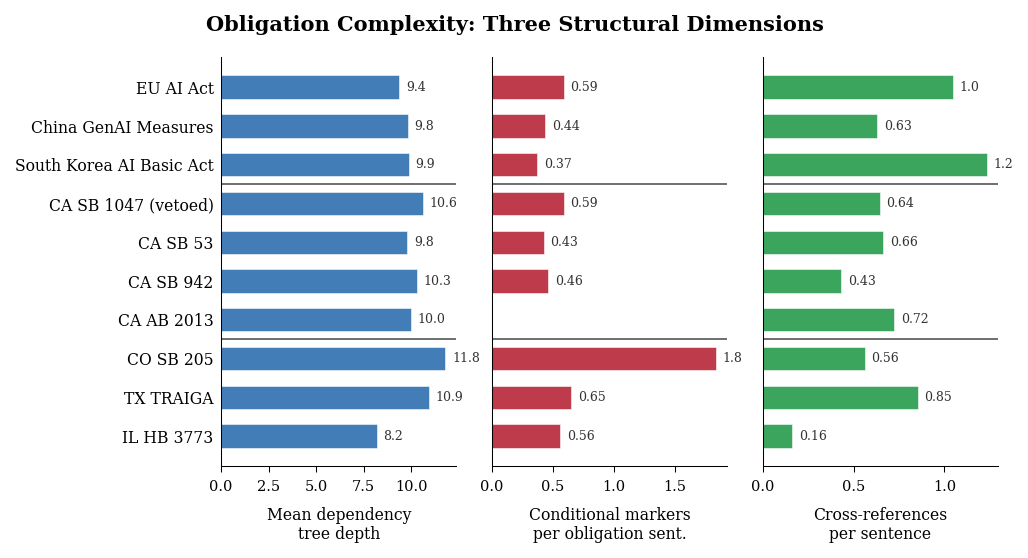

Saved: /content/drive/MyDrive/ACL SRW TEXTS/figures/fig4a_complexity_grouped.pdf


In [ ]:
# ── Cell 6: Figure 4a — Grouped bar chart ──

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig_a, axes = plt.subplots(1, 3, figsize=(7.0, 3.5), dpi=150, sharey=True)

ylabels = [LAW_LABELS[lid] for lid in LAW_ORDER]
y_pos = np.arange(len(LAW_ORDER))

metric_configs = [
    ("Mean Tree Depth", "#2166ac", "Mean dependency\ntree depth"),
    ("Conditional Density", "#b2182b", "Conditional markers\nper obligation sent."),
    ("Cross-Ref Density", "#1a9641", "Cross-references\nper sentence"),
]

for ax, (col, color, xlabel) in zip(axes, metric_configs):
    vals = metrics_df[col].values
    ax.barh(y_pos, vals, height=0.6, color=color, edgecolor="white",
            linewidth=0.3, alpha=0.85)

    # Value annotations
    for i, v in enumerate(vals):
        if v > 0.01:
            fmt = f"{v:.1f}" if v >= 1 else f"{v:.2f}"
            ax.text(v + (vals.max() * 0.03), i, fmt,
                    ha="left", va="center", fontsize=6, color="#333333")

    ax.set_xlabel(xlabel, fontsize=7.5, labelpad=6)
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_linewidth(0.5)
    ax.tick_params(axis="x", labelsize=7, length=3, width=0.5)
    ax.tick_params(axis="y", length=0)

    # Jurisdiction dividers
    for y_line in [2.5, 6.5]:
        ax.axhline(y=y_line, color="#555555", linewidth=0.8)

# Y-axis labels only on leftmost panel
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(ylabels, fontsize=7.5)

fig_a.suptitle("Obligation Complexity: Three Structural Dimensions",
               fontweight="bold", fontsize=10, y=0.98)

fig_a.subplots_adjust(left=0.22, right=0.96, top=0.90, bottom=0.12,
                      wspace=0.15)
fig_a.savefig(FIGURE_DIR / "fig4a_complexity_grouped.pdf", dpi=1200,
              bbox_inches="tight", pad_inches=0.08)
plt.show()
print(f"Saved: {FIGURE_DIR / 'fig4a_complexity_grouped.pdf'}")

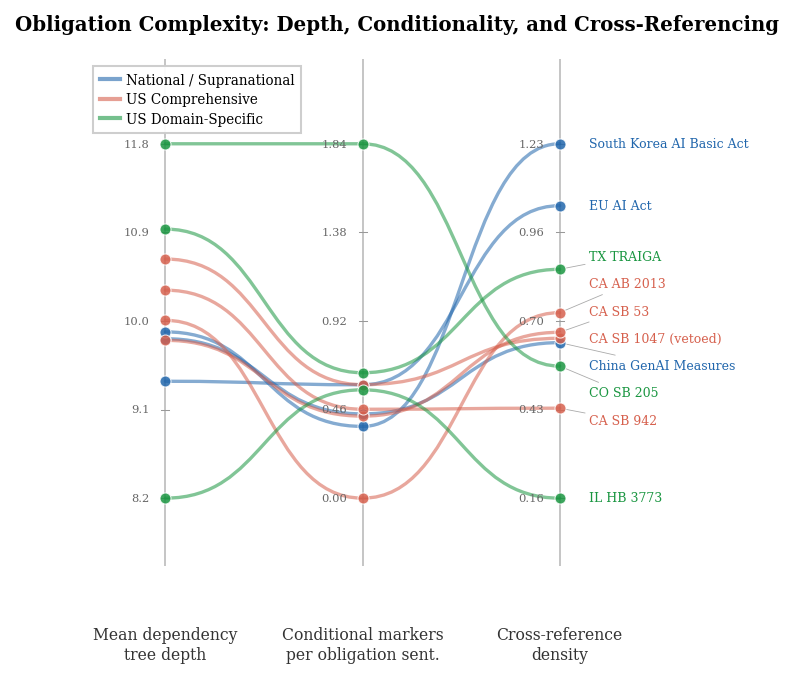

Saved: /content/drive/MyDrive/ACL SRW TEXTS/figures/fig4b_complexity_parallel.pdf


In [ ]:
# ── Cell 7: Figure 4b — Parallel Coordinates Plot ──

from matplotlib.lines import Line2D
from matplotlib.path import Path
import matplotlib.patches as mpatches

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "mathtext.fontset": "stix",
})

fig_b, ax_b = plt.subplots(figsize=(6.0, 4.5), dpi=150)

# ── Data ──
depths = metrics_df["Mean Tree Depth"].values
conditionals = metrics_df["Conditional Density"].values
crossrefs = metrics_df["Cross-Ref Density"].values

raw_data = np.column_stack([depths, conditionals, crossrefs])
axis_labels = [
    "Mean dependency\ntree depth",
    "Conditional markers\nper obligation sent.",
    "Cross-reference\ndensity",
]
n_axes = 3

# Normalize each dimension to [0, 1] with padding
mins = raw_data.min(axis=0)
maxs = raw_data.max(axis=0)
pad = 0.08
ranges = maxs - mins
ranges[ranges == 0] = 1
normed = (raw_data - mins) / ranges
normed = normed * (1 - 2 * pad) + pad

# Tier assignments
tier_map = {
    "eu_ai_act": 0, "china_genai": 0, "south_korea": 0,
    "ca_sb1047": 1, "ca_sb53": 1, "ca_sb942": 1, "ca_ab2013": 1,
    "co_sb205": 2, "tx_traiga": 2, "il_hb3773": 2,
}
tier_colors_list = ["#2166ac", "#d6604d", "#1a9641"]
tier_names = ["National / Supranational", "US Comprehensive", "US Domain-Specific"]

x_pos = np.array([0, 1, 2])

# ── Draw vertical axis spines ──
for xp in x_pos:
    ax_b.axvline(x=xp, color="#bbbbbb", linewidth=0.8, zorder=1)

# ── Draw Bezier curves ──
for i, lid in enumerate(LAW_ORDER):
    tier = tier_map[lid]
    color = tier_colors_list[tier]
    ys = normed[i]

    verts = []
    codes = []
    for j in range(n_axes - 1):
        x0, y0 = x_pos[j], ys[j]
        x1, y1 = x_pos[j + 1], ys[j + 1]
        mid = (x0 + x1) / 2
        if j == 0:
            verts.append((x0, y0))
            codes.append(Path.MOVETO)
        verts.extend([(mid, y0), (mid, y1), (x1, y1)])
        codes.extend([Path.CURVE4, Path.CURVE4, Path.CURVE4])

    path = Path(verts, codes)
    patch = mpatches.FancyArrowPatch(
        path=path, arrowstyle="-", color=color,
        linewidth=1.6, alpha=0.55, zorder=2,
    )
    ax_b.add_patch(patch)

    for j in range(n_axes):
        ax_b.scatter(x_pos[j], ys[j], s=28, color=color,
                     edgecolors="white", linewidths=0.5, zorder=4, alpha=0.85)

# ── Law labels on the right — increased gap and bidirectional repulsion ──
label_data = []
for i, lid in enumerate(LAW_ORDER):
    label_data.append({
        "lid": lid,
        "y": normed[i, 2],
        "tier": tier_map[lid],
    })
label_data.sort(key=lambda d: d["y"])

# Iterative bidirectional repulsion (multiple passes)
min_gap = 0.065
for d in label_data:
    d["label_y"] = d["y"]

for _ in range(20):  # iterate until stable
    moved = False
    for idx in range(1, len(label_data)):
        prev_y = label_data[idx - 1]["label_y"]
        curr_y = label_data[idx]["label_y"]
        if curr_y - prev_y < min_gap:
            overlap = min_gap - (curr_y - prev_y)
            # Push both apart symmetrically
            label_data[idx - 1]["label_y"] -= overlap * 0.5
            label_data[idx]["label_y"] += overlap * 0.5
            moved = True
    if not moved:
        break

for d in label_data:
    lid = d["lid"]
    color = tier_colors_list[d["tier"]]
    displacement = abs(d["label_y"] - d["y"])

    # Leader line if label displaced significantly
    arrow_props = None
    if displacement > 0.02:
        arrow_props = dict(
            arrowstyle="-", color="#aaaaaa",
            linewidth=0.4, shrinkA=0, shrinkB=3,
        )

    ax_b.annotate(
        LAW_LABELS[lid],
        xy=(x_pos[-1], d["y"]),
        xytext=(x_pos[-1] + 0.15, d["label_y"]),
        fontsize=6, color=color, fontweight="medium",
        ha="left", va="center",
        arrowprops=arrow_props,
    )

# ── Axis tick labels (original scale) ──
n_ticks = 5
for j in range(n_axes):
    tick_normed = np.linspace(pad, 1 - pad, n_ticks)
    tick_real = mins[j] + (tick_normed - pad) / (1 - 2 * pad) * ranges[j]
    for tn, tr in zip(tick_normed, tick_real):
        fmt = f"{tr:.1f}" if j == 0 else f"{tr:.2f}"
        # All tick labels on the left of their axis
        ax_b.text(x_pos[j] - 0.08, tn, fmt,
                  fontsize=5.5, color="#666666", ha="right", va="center")
    for tn in tick_normed:
        ax_b.plot([x_pos[j] - 0.02, x_pos[j] + 0.02], [tn, tn],
                  color="#999999", linewidth=0.5, zorder=1)

# ── Axis titles at bottom ──
for j in range(n_axes):
    ax_b.text(x_pos[j], -0.12, axis_labels[j],
              fontsize=7.5, ha="center", va="top", color="#333333",
              transform=ax_b.get_xaxis_transform())

# ── Legend ──
tier_handles = [
    Line2D([0], [0], color=tier_colors_list[t], linewidth=2.0,
           alpha=0.6, label=tier_names[t])
    for t in range(3)
]
leg = ax_b.legend(handles=tier_handles, loc="upper left",
                  bbox_to_anchor=(0.0, 1.0),
                  fontsize=6.5, frameon=True, framealpha=0.95,
                  edgecolor="#cccccc", fancybox=False,
                  handlelength=1.5, handletextpad=0.4, labelspacing=0.4,
                  borderpad=0.5)

# ── Clean up ──
ax_b.set_xlim(-0.40, 2.75)
ax_b.set_ylim(-0.08, 1.12)
ax_b.set_xticks([])
ax_b.set_yticks([])
for spine in ax_b.spines.values():
    spine.set_visible(False)

ax_b.set_title("Obligation Complexity: Depth, Conditionality, and Cross-Referencing",
               pad=14, fontweight="bold", fontsize=9.5)

fig_b.subplots_adjust(left=0.06, right=0.75, top=0.88, bottom=0.13)
fig_b.savefig(FIGURE_DIR / "fig4b_complexity_parallel.pdf", dpi=1200,
              bbox_inches="tight", pad_inches=0.08)
plt.show()
print(f"Saved: {FIGURE_DIR / 'fig4b_complexity_parallel.pdf'}")

In [ ]:
# ── Cell 8: Export ──

export = {}
for law_id in LAW_ORDER:
    export[law_id] = {
        "depth": {
            "mean": depth_results[law_id]["mean"],
            "median": depth_results[law_id]["median"],
            "std": depth_results[law_id]["std"],
            "n": depth_results[law_id]["n"],
        },
        "conditional": {
            "total": conditional_results[law_id]["total_conditionals"],
            "n_obligation": conditional_results[law_id]["n_obligation"],
            "density": conditional_results[law_id]["density"],
        },
        "crossref": {
            "total": crossref_results[law_id]["total_refs"],
            "total_sentences": crossref_results[law_id]["total_sentences"],
            "density": crossref_results[law_id]["density"],
        },
    }

export_path = OUTPUT_DIR / "technique3_complexity.json"
with open(export_path, "w", encoding="utf-8") as f:
    json.dump(export, f, indent=2)
print(f"\nResults saved to: {export_path}")


Results saved to: /content/drive/MyDrive/ACL SRW TEXTS/processed/technique3_complexity.json
